# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## **Deskripsi Dataset**
Pada proyek ini, saya menggunakan **Early Stage Diabetes Risk Prediction Dataset**. Data ini dikumpulkan menggunakan kuesioner langsung dari pasien Rumah Sakit Diabetes Sylhet di Sylhet, Bangladesh, dan telah disetujui oleh dokter.

Dataset ini digunakan untuk memprediksi kemungkinan seseorang menderita diabetes pada tahap awal berdasarkan gejala fisik dan klinis. Target prediksi adalah variabel `class`, yang bernilai **Positive** (Berisiko Diabetes) atau **Negative** (Tidak Berisiko).

**Sumber Dataset:**
Dataset ini dapat diunduh dari [Kaggle](https://www.kaggle.com/datasets/ishandutta/early-stage-diabetes-risk-prediction-dataset).

## **Informasi Atribut**
Dataset ini terdiri dari **520 data** (baris) dan **17 atribut** (kolom). Sebagian besar atribut bersifat kategorikal (Yes/No). Berikut adalah penjelasan dari setiap fitur:

| Nama Kolom | Deskripsi | Tipe Data |
| :--- | :--- | :--- |
| **Age** | Umur pasien (20-65 tahun) | Numerik |
| **Gender** | Jenis kelamin (Male/Female) | Kategorikal |
| **Polyuria** | Gejala sering buang air kecil | Kategorikal (Yes/No) |
| **Polydipsia** | Gejala sering merasa haus berlebihan | Kategorikal (Yes/No) |
| **Sudden weight loss** | Penurunan berat badan secara tiba-tiba | Kategorikal (Yes/No) |
| **Weakness** | Merasa lemah atau lelah | Kategorikal (Yes/No) |
| **Polyphagia** | Gejala sering merasa lapar berlebihan | Kategorikal (Yes/No) |
| **Genital thrush** | Infeksi jamur pada area genital (kandidiasis) | Kategorikal (Yes/No) |
| **visual blurring** | Penglihatan kabur | Kategorikal (Yes/No) |
| **Itching** | Gatal-gatal pada kulit | Kategorikal (Yes/No) |
| **Irritability** | Mudah marah atau tersinggung | Kategorikal (Yes/No) |
| **delayed healing** | Penyembuhan luka yang lambat | Kategorikal (Yes/No) |
| **partial paresis** | Pelemahan otot ringan/parsial | Kategorikal (Yes/No) |
| **muscle stiffness** | Kekakuan otot | Kategorikal (Yes/No) |
| **Alopecia** | Kerontokan rambut | Kategorikal (Yes/No) |
| **Obesity** | Obesitas / kegemukan | Kategorikal (Yes/No) |
| **class** | **(Target)** Diagnosis Diabetes (Positive/Negative) | Kategorikal (Target) |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('../diabetes_data.csv')
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25264\2833642139.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


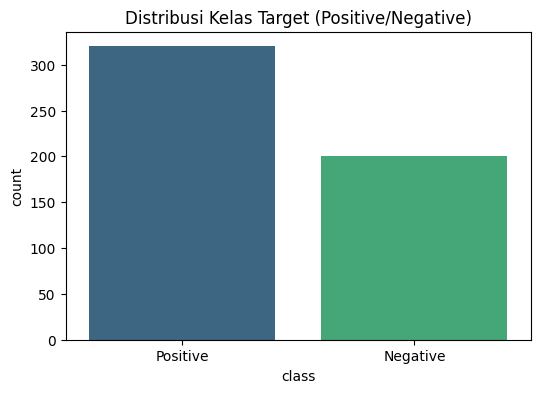

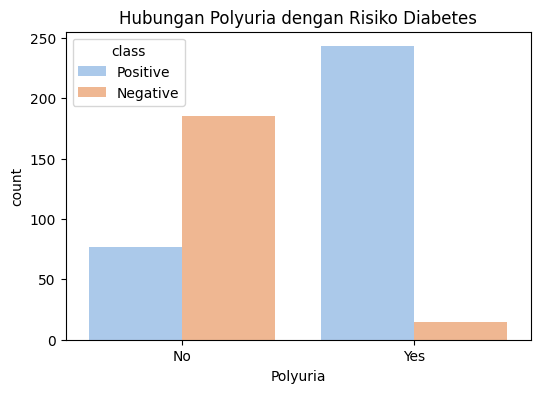

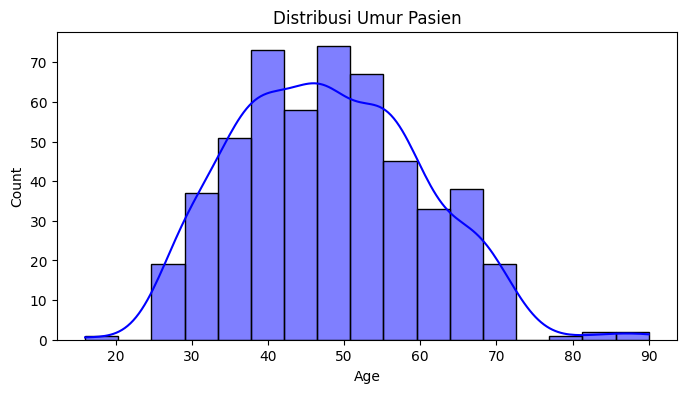

In [3]:
# Cek Info Data
print(df.info())

# Cek Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Cek Duplikasi
print(f"\nJumlah Duplikat: {df.duplicated().sum()}")

# Visualisasi Target Class
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribusi Kelas Target (Positive/Negative)')
plt.show()

# Visualisasi Fitur Kategorikal
plt.figure(figsize=(6, 4))
sns.countplot(x='Polyuria', hue='class', data=df, palette='pastel')
plt.title('Hubungan Polyuria dengan Risiko Diabetes')
plt.show()

# Distribusi Umur
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Distribusi Umur Pasien')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Hapus Duplikasi
df = df.drop_duplicates()
print(f"\nJumlah Duplikat: {df.duplicated().sum()}")

# Encoding
le = LabelEncoder()
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = le.fit_transform(df[col])

print("Data setelah encoding:")
display(df.head())

# Splitting Features & Target
X = df.drop('class', axis=1)
y = df['class']

# Normalisasi (StandardScaler untuk Age)
scaler = StandardScaler()
X['Age'] = scaler.fit_transform(X[['Age']])

# Simpan Data Bersih
df_clean = pd.concat([X, y], axis=1)
df_clean.to_csv('diabetes_data_preprocessed.csv', index=False)
print("Data bersih disimpan sebagai diabetes_data_preprocessed.csv")


Jumlah Duplikat: 0
Data setelah encoding:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


Data bersih disimpan sebagai diabetes_data_preprocessed.csv
